# LSTM retrain - best hyperparameters
### Anaerobic Digestion of Olive Mill Waste - Crete Case Study

---

## results from LSTM K-Fold search:

the LSTM K-Fold search evaluated 45 combinations across 6 folds and the results
were the strongest of any model tested so far

**K-Fold best combination:** hidden_dim=30, lr=0.001, batch=25

**K-Fold avg validation loss comparison:**

| model | K-Fold best avg val loss | std |
|-------|--------------------------|-----|
| ANN | 0.025906 | 0.008138 |
| RNN | 0.000102 | 0.000016 |
| LSTM | 0.000031 | 0.000007 |

the LSTM K-Fold best is 3.3 times lower than the RNN best and 836 times lower
than the ANN best. the standard deviation of 0.000007 across folds indicates
very stable generalisation. the six individual fold losses were 0.000043,
0.000024, 0.000024, 0.000028, 0.000033, and 0.000035, with the highest fold
only 1.8 times the lowest

**best hyperparameters found:**

| hyperparameter | 1st run | K-Fold best |
|----------------|-----------|-------------|
| hidden_dim | 20 | 30 |
| learning rate | 0.001 | 0.001 |
| batch size | 50 | 25 |
| layer_dim | 2 | 2 (unchanged) |

the pattern matches the RNN K-Fold finding, both recurrent architectures
prefer hidden_dim=30, lr=0.001 and batch=25. this consistency across the 2
different architectures suggests these are the best values for this
dataset rather than noise

**reason why this retrain uses the full augmented dataset:**

the K-Fold used the 648 clean sequences for speed and fair comparison. this
retrain uses all 16,200 augmented sequences, giving the model
more data to learn from. the K-Fold identifies the best architecture then the
retrain builds the strongest possible model using that architecture

**critical open question:**

the LSTM's K-Fold validation loss is way lower than the RNN. the
question is whether this advantage survives the offline testing, where
the RNN failed due to error accumulation in the predicted sequence window. the
LSTM forget gate may reduce this problem by selectively discarding corrupted
historical states. testing will determine whether this theoretical advantage
translates to real world improvement


## 1. Imports

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import openpyxl
from sklearn.preprocessing import StandardScaler

torch.manual_seed(42)
np.random.seed(42)

print("torch version:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

torch version: 2.11.0
cuda available: False


## 2. Hyperparameters

In [2]:
input_dim    = 5
hidden_dim   = 30
layer_dim    = 2
output_dim   = 3

seq_len       = 12
N             = 25
learning_rate = 1e-3
train_epochs  = 300

print("hyperparameters:")
print(f"  architecture : LSTMModel({input_dim}, {hidden_dim}, {layer_dim}, {output_dim})")
print(f"  sequence len : {seq_len}")
print(f"  batch size   : {N}")
print(f"  learning rate: {learning_rate}")
print(f"  epochs       : {train_epochs}")
params = layer_dim * 4 * hidden_dim * (input_dim + hidden_dim + 1) + output_dim * (hidden_dim + 1)
print(f"  parameters   : approx {params}")
print(f"  first run had LSTMModel(5, 20, 2, 3)")

hyperparameters:
  architecture : LSTMModel(5, 30, 2, 3)
  sequence len : 12
  batch size   : 25
  learning rate: 0.001
  epochs       : 300
  parameters   : approx 8733
  first run had LSTMModel(5, 20, 2, 3)


## 3. Load Data

In [3]:
book = openpyxl.load_workbook('olive_mill_database.xlsx',
                               read_only=True, data_only=True)

sheet_ref = book['STANDARDISATION_REF']
data_ref  = []
for r in sheet_ref.iter_rows(min_row=4, values_only=True):
    data_ref.append([r[c] for c in range(8)])

print(f"reference data: {len(data_ref)} rows")

reference data: 1080 rows


## 4. Standardise

In [4]:
scaler = StandardScaler()
scaler.fit(data_ref)

print("scaler fitted")
print("means: ", [round(m, 3) for m in scaler.mean_])
print("stds:  ", [round(s, 3) for s in scaler.scale_])

scaler fitted
means:  [np.float64(17.244), np.float64(6747.284), np.float64(7.109), np.float64(36.25), np.float64(3.333), np.float64(-0.928), np.float64(352.734), np.float64(-0.013)]
stds:   [np.float64(12.582), np.float64(4702.294), np.float64(0.156), np.float64(4.38), np.float64(2.055), np.float64(0.754), np.float64(286.686), np.float64(0.016)]


## 5. Create Sequences and Augment

In [5]:
std_ref  = scaler.transform(data_ref)
x_ref    = std_ref[:, 0:5]
y_ref    = std_ref[:, 5:8]

n_runs       = 36
rows_per_run = 30

sequences_x = []
sequences_y = []

for run_i in range(n_runs):
    start = run_i * rows_per_run
    end   = start + rows_per_run
    run_x = x_ref[start:end]
    run_y = y_ref[start:end]
    for t in range(rows_per_run - seq_len):
        sequences_x.append(run_x[t : t + seq_len])
        sequences_y.append(run_y[t + seq_len - 1])

sequences_x = np.array(sequences_x)
sequences_y = np.array(sequences_y)

print(f"clean sequences: {sequences_x.shape}")

NOISE_LEVEL  = 0.05 * 0.333
REPLICATIONS = 25

aug_x = []
aug_y = []

for i in range(len(sequences_x)):
    base_x = sequences_x[i]
    base_y = sequences_y[i]
    for _ in range(REPLICATIONS):
        noisy_x = np.random.normal(base_x, np.abs(base_x) * NOISE_LEVEL + 1e-6)
        noisy_y = np.random.normal(base_y, np.abs(base_y) * NOISE_LEVEL + 1e-6)
        aug_x.append(noisy_x)
        aug_y.append(noisy_y)

aug_x = np.array(aug_x)
aug_y = np.array(aug_y)

idx   = np.random.permutation(len(aug_x))
aug_x = aug_x[idx]
aug_y = aug_y[idx]

x_train = torch.tensor(aug_x, dtype=torch.float32)
y_train = torch.tensor(aug_y, dtype=torch.float32)

print(f"augmented sequences: {x_train.shape}")
print(f"augmented targets  : {y_train.shape}")

clean sequences: (648, 12, 5)
augmented sequences: torch.Size([16200, 12, 5])
augmented targets  : torch.Size([16200, 3])


## 6. Define Model

In [6]:
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, layer_dim, output_dim):
        super(LSTMModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.layer_dim  = layer_dim
        self.lstm = nn.LSTM(input_dim, hidden_dim, layer_dim,
                            batch_first=True)
        self.fc   = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0  = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim)
        c0  = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim)
        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))
        out = self.fc(out[:, -1, :])
        return out

model   = LSTMModel(input_dim, hidden_dim, layer_dim, output_dim)
loss_fn = nn.MSELoss(reduction='mean')

print("model:")
print(model)
print()
actual_params = sum(p.numel() for p in model.parameters())
print(f"actual parameters: {actual_params}")
test = model(x_train[:N])
print(f"forward pass OK: output shape {test.shape}")

model:
LSTMModel(
  (lstm): LSTM(5, 30, num_layers=2, batch_first=True)
  (fc): Linear(in_features=30, out_features=3, bias=True)
)

actual parameters: 11973
forward pass OK: output shape torch.Size([25, 3])


## 7. DataLoader

In [7]:
dataset    = torch.utils.data.TensorDataset(x_train, y_train)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=N, shuffle=True)

print(f"dataset size  : {len(dataset)} sequences")
print(f"batch size    : {N}")
print(f"batches/epoch : {len(dataloader)}")
print(f"updates/epoch : {len(dataloader)}")

dataset size  : 16200 sequences
batch size    : 25
batches/epoch : 648
updates/epoch : 648


## 8. Train

In [8]:
optimizer    = torch.optim.Adam(model.parameters(), lr=learning_rate)
loss_history = []

model.train()
print(f"training: {train_epochs} epochs, lr={learning_rate}, batch={N}")
print("-" * 58)

for epoch in range(train_epochs):
    epoch_loss = 0.0
    for x_batch, y_batch in dataloader:
        y_pred = model(x_batch)
        loss   = loss_fn(y_pred, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() / len(dataloader)
    loss_history.append(epoch_loss)
    if epoch % 25 == 0 or epoch == train_epochs - 1:
        print(f"epoch {epoch:>4d}   loss = {epoch_loss:.7f}")

print("-" * 58)
print(f"done.")
print(f"final loss      : {loss_history[-1]:.7f}")
print(f"RNN first run   : 0.0001380")
print(f"LSTM first run  : 0.0001193")
print(f"improvement over LSTM first run: "
      f"{((0.0001193 - loss_history[-1])/0.0001193)*100:.1f}%")

training: 300 epochs, lr=0.001, batch=25
----------------------------------------------------------
epoch    0   loss = 0.0158427
epoch   25   loss = 0.0001485
epoch   50   loss = 0.0001438
epoch   75   loss = 0.0001316
epoch  100   loss = 0.0001301
epoch  125   loss = 0.0001253
epoch  150   loss = 0.0001220
epoch  175   loss = 0.0001210
epoch  200   loss = 0.0001210
epoch  225   loss = 0.0001181
epoch  250   loss = 0.0001173
epoch  275   loss = 0.0001160
epoch  299   loss = 0.0001144
----------------------------------------------------------
done.
final loss      : 0.0001144
RNN first run   : 0.0001380
LSTM first run  : 0.0001193
improvement over LSTM first run: 4.1%


## 9. Loss Curve

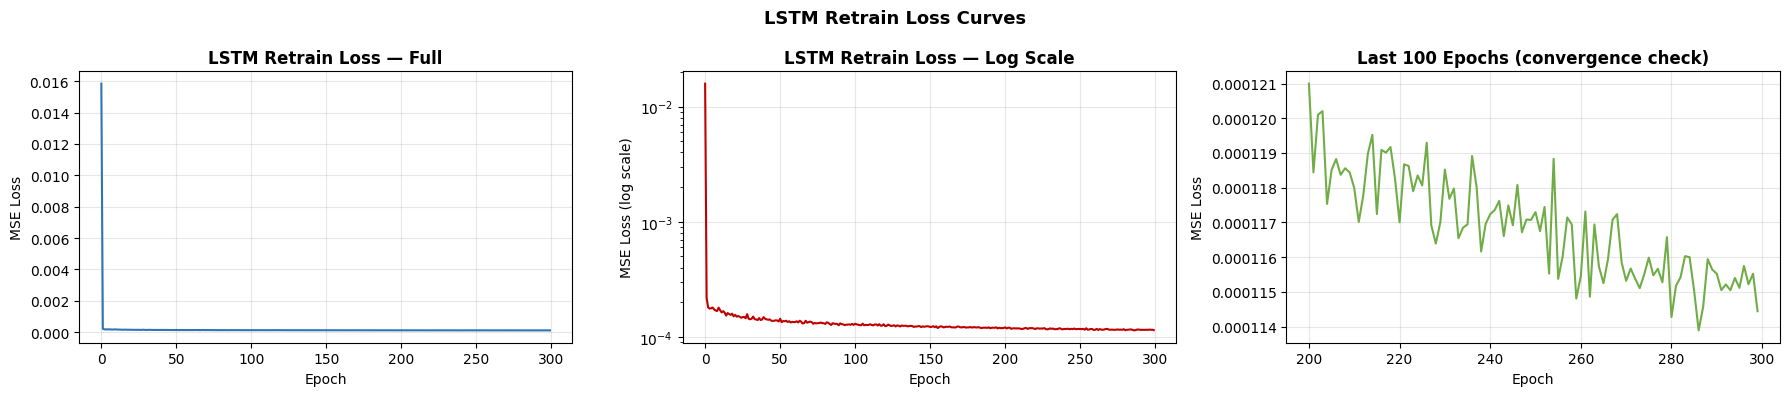

loss drop in last  50 epochs: 0.00000285
loss drop in last 100 epochs: 0.00000655
CONVERGED


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(loss_history, color='#2E75B6', linewidth=1.5)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('LSTM Retrain Loss — Full', fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].semilogy(loss_history, color='#C00000', linewidth=1.5)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss (log scale)')
axes[1].set_title('LSTM Retrain Loss — Log Scale', fontweight='bold')
axes[1].grid(True, alpha=0.3)

axes[2].plot(range(train_epochs-100, train_epochs),
             loss_history[-100:], color='#70AD47', linewidth=1.5)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('MSE Loss')
axes[2].set_title('Last 100 Epochs (convergence check)', fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.suptitle('LSTM Retrain Loss Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

last50_drop  = loss_history[-50]  - loss_history[-1]
last100_drop = loss_history[-100] - loss_history[-1]
print(f"loss drop in last  50 epochs: {last50_drop:.8f}")
print(f"loss drop in last 100 epochs: {last100_drop:.8f}")
if last50_drop < 0.000005:
    print("CONVERGED")
elif last50_drop < 0.00002:
    print("nearly converged")
else:
    print("still decreasing — consider more epochs")

## 10. Predicted vs Actual

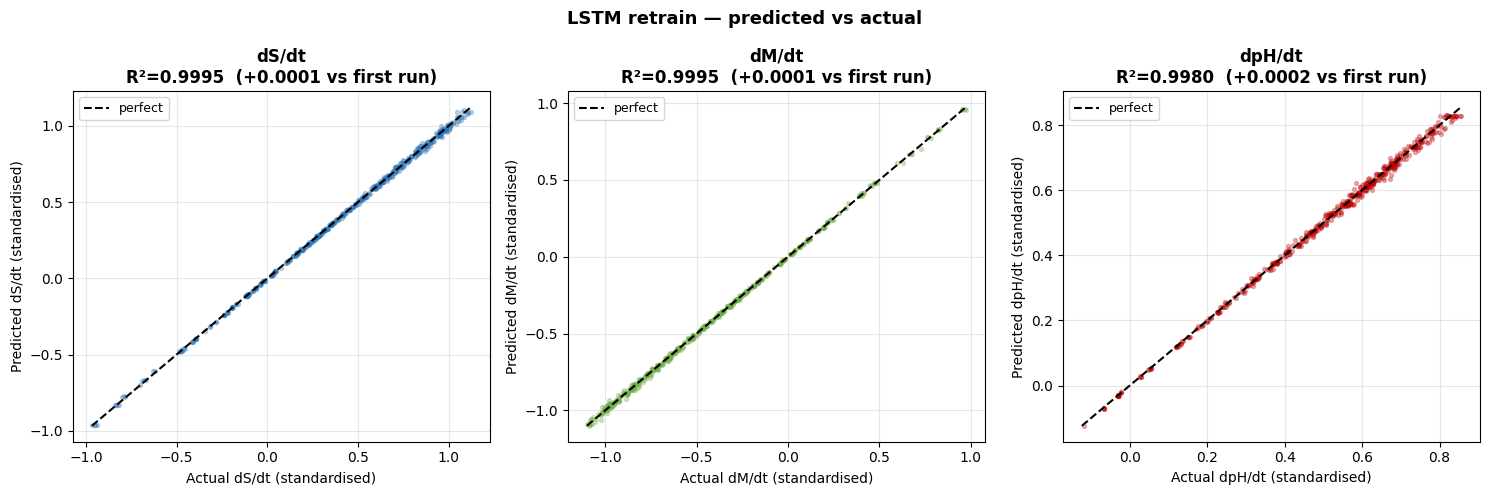

R² comparison (retrain vs first run):
                First Run      retrain     change
-----------------------------------------------
  dS/dt            0.9994       0.9995    +0.0001
  dM/dt            0.9994       0.9995    +0.0001
  dpH/dt           0.9978       0.9980    +0.0002


In [13]:
model.eval()
with torch.no_grad():
    sample_x = x_train[:500]
    sample_y = y_train[:500]
    preds    = model(sample_x)

preds_np  = preds.numpy()
actual_np = sample_y.numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
target_names  = ['dS/dt', 'dM/dt', 'dpH/dt']
colors        = ['#2E75B6', '#70AD47', '#C00000']
lstm_first_r2 = [0.9994, 0.9994, 0.9978]

r2_vals = []
for i, (ax, name, col, fr2) in enumerate(
        zip(axes, target_names, colors, lstm_first_r2)):
    ax.scatter(actual_np[:, i], preds_np[:, i],
               alpha=0.3, s=8, color=col)
    lims = [min(actual_np[:,i].min(), preds_np[:,i].min()),
            max(actual_np[:,i].max(), preds_np[:,i].max())]
    ax.plot(lims, lims, 'k--', linewidth=1.5, label='perfect')
    ss_res = np.sum((actual_np[:,i] - preds_np[:,i])**2)
    ss_tot = np.sum((actual_np[:,i] - actual_np[:,i].mean())**2)
    r2     = 1 - ss_res / ss_tot
    r2_vals.append(r2)
    delta  = r2 - fr2
    delta_str = f'+{delta:.4f}' if delta >= 0 else f'{delta:.4f}'
    ax.set_xlabel(f'Actual {name} (standardised)')
    ax.set_ylabel(f'Predicted {name} (standardised)')
    ax.set_title(f'{name}\nR²={r2:.4f}  ({delta_str} vs first run)',
                 fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('LSTM retrain — predicted vs actual',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("R² comparison (retrain vs first run):")
print(f"{'':12} {'First Run':>12} {'retrain':>12} {'change':>10}")
print("-" * 47)
for name, r2, fr2 in zip(target_names, r2_vals, lstm_first_r2):
    delta     = r2 - fr2
    delta_str = f'+{delta:.4f}' if delta >= 0 else f'{delta:.4f}'
    print(f"  {name:<10} {fr2:>12.4f} {r2:>12.4f} {delta_str:>10}")

## 11. Save Model

In [14]:
torch.save(model.state_dict(), 'LSTM_olive_mill_retrained.pt')
np.save('scaler_mean.npy',  scaler.mean_)
np.save('scaler_scale.npy', scaler.scale_)

print("saved:")
print("  LSTM_olive_mill_retrained.pt")
print("  scaler_mean.npy")
print("  scaler_scale.npy")
print()
print("to reload in testing notebook:")
print(f"  model = LSTMModel({input_dim}, {hidden_dim}, {layer_dim}, {output_dim})")
print("  model.load_state_dict(torch.load('LSTM_olive_mill_retrained.pt'))")
print("  model.eval()")

saved:
  LSTM_olive_mill_retrained.pt
  scaler_mean.npy
  scaler_scale.npy

to reload in testing notebook:
  model = LSTMModel(5, 30, 2, 3)
  model.load_state_dict(torch.load('LSTM_olive_mill_retrained.pt'))
  model.eval()
